# Recurrence Quantification Analysis (RQA) on a time series

This notebook computes RQA on a single column of a `.csv` time series.

**Example:** the acoustic envelope from `Datasets/BalanceCorpus/TS_acoustics/env_..._flower_ground.wav_norm.csv`, column `envelope`.

Pipeline:
1. Load the CSV and select a column.
2. *(Optional)* Time-delay embed the signal (Takens embedding). Choose `EMBED_DIM` and `TAU`; set `EMBED_DIM = 1` to skip embedding.
3. Build the recurrence matrix and quantify it (RR, DET, L, ENTR, LAM, TT, ...).
4. Plot the recurrence plot.

Uses [`PyRQA`](https://pypi.org/project/PyRQA/). Install with `pip install PyRQA` if needed.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.analysis_type import Classic
from pyrqa.neighbourhood import FixedRadius
from pyrqa.metric import EuclideanMetric
from pyrqa.computation import RQAComputation, RPComputation

## 1. Parameters

Edit these to point at a different file / column, or to change the embedding and recurrence threshold.

In [8]:
# --- Data ---
CSV_PATH = "../../../Datasets/BalanceCorpus/TS_acoustics/env_116_216_34_1_20250116_103225_flower_ground.wav_norm.csv"
COLUMN   = "envelope"      # column to analyze

# --- Embedding (Takens time-delay). Set EMBED_DIM=1 to skip embedding. ---
EMBED_DIM = 3              # number of embedding dimensions (1 = no embedding)
TAU       = 10            # delay in samples between embedding dimensions

# --- Recurrence ---
# RADIUS is the distance threshold that counts two states as 'recurrent'.
# A common heuristic is to pick it so recurrence rate (RR) lands around 1-5%.
RADIUS    = None           # None -> auto-pick from a target RR below
TARGET_RR = 0.05           # used only when RADIUS is None

# --- Optional: z-score normalize the signal before RQA (recommended) ---
ZSCORE = True

## 2. Load and select the column

Loaded 5190 rows, columns: ['time', 'audio', 'envelope', 'filename', 'envelope_norm', 'envelope_change']
Signal 'envelope': 5190 samples, mean=-0.000, std=1.000


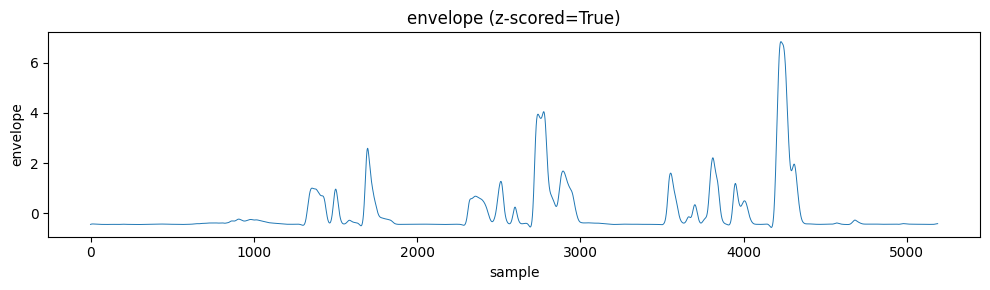

In [9]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {df.shape[0]} rows, columns: {list(df.columns)}")

signal = df[COLUMN].to_numpy(dtype=float)
# drop NaNs (keeps it simple; for gaps consider interpolation instead)
signal = signal[~np.isnan(signal)]

if ZSCORE:
    signal = (signal - signal.mean()) / signal.std()

print(f"Signal '{COLUMN}': {signal.shape[0]} samples, "
      f"mean={signal.mean():.3f}, std={signal.std():.3f}")

plt.figure(figsize=(10, 3))
plt.plot(signal, lw=0.7)
plt.title(f"{COLUMN} (z-scored={ZSCORE})")
plt.xlabel("sample"); plt.ylabel(COLUMN)
plt.tight_layout(); plt.show()

## 3. Build the (optionally embedded) TimeSeries

`PyRQA`'s `TimeSeries` does the time-delay embedding internally when given `embedding_dimension` and `time_delay`. The reconstructed phase space has `N - (EMBED_DIM-1)*TAU` points.

In [10]:
time_series = TimeSeries(signal,
                         embedding_dimension=EMBED_DIM,
                         time_delay=TAU)

n_vectors = len(signal) - (EMBED_DIM - 1) * TAU
print(f"Embedding dim={EMBED_DIM}, tau={TAU} -> {n_vectors} phase-space vectors")

Embedding dim=3, tau=10 -> 5170 phase-space vectors


## 4. Pick the recurrence radius

If `RADIUS` is `None`, we sweep a few candidate radii and pick the one whose recurrence rate is closest to `TARGET_RR`. Otherwise the fixed value is used directly.

In [11]:
def rqa_for_radius(radius):
    settings = Settings(time_series,
                        analysis_type=Classic,
                        neighbourhood=FixedRadius(radius),
                        similarity_measure=EuclideanMetric,
                        theiler_corrector=1)
    result = RQAComputation.create(settings).run()
    result.min_diagonal_line_length = 2
    result.min_vertical_line_length = 2
    result.min_white_vertical_line_length = 2
    return settings, result

if RADIUS is None:
    # rough scale from pairwise spread of the signal amplitude
    candidates = np.linspace(0.05, 2.5, 25) * signal.std()
    best = None
    for r in candidates:
        _, res = rqa_for_radius(r)
        rr = res.recurrence_rate
        if best is None or abs(rr - TARGET_RR) < abs(best[1] - TARGET_RR):
            best = (r, rr)
    RADIUS = float(best[0])
    print(f"Auto-selected RADIUS={RADIUS:.4f} (RR={best[1]:.3f}, target={TARGET_RR})")
else:
    print(f"Using fixed RADIUS={RADIUS}")

Auto-selected RADIUS=0.0500 (RR=0.228, target=0.05)


## 5. Compute RQA metrics

In [12]:
settings, result = rqa_for_radius(RADIUS)
print(result)

metrics = {
    "Recurrence rate (RR)":        result.recurrence_rate,
    "Determinism (DET)":           result.determinism,
    "Avg diagonal line (L)":       result.average_diagonal_line,
    "Longest diagonal (Lmax)":     result.longest_diagonal_line,
    "Divergence (1/Lmax)":         result.divergence,
    "Entropy (ENTR)":              result.entropy_diagonal_lines,
    "Laminarity (LAM)":            result.laminarity,
    "Trapping time (TT)":          result.trapping_time,
    "Longest vertical (Vmax)":     result.longest_vertical_line,
}
metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["value"])
metrics_df

RQA Result:

Minimum diagonal line length (L_min): 2
Minimum vertical line length (V_min): 2
Minimum white vertical line length (W_min): 2

Recurrence rate (RR): 0.227949
Determinism (DET): 0.999777
Average diagonal line length (L): 102.895959
Longest diagonal line length (L_max): 1304
Divergence (DIV): 0.000767
Entropy diagonal lines (L_entr): 5.351316
Laminarity (LAM): 0.999674
Trapping time (TT): 159.793189
Longest vertical line length (V_max): 714
Entropy vertical lines (V_entr): 5.083522
Average white vertical line length (W): 511.666063
Longest white vertical line length (W_max): 4333
Longest white vertical line length inverse (W_div): 0.000231
Entropy white vertical lines (W_entr): 6.327546

Ratio determinism / recurrence rate (DET/RR): 4.385972
Ratio laminarity / determinism (LAM/DET): 0.999897



,value
Recurrence rate (RR),0.227949
Determinism (DET),0.999777
Avg diagonal line (L),102.895959
Longest diagonal (Lmax),1304.000000
Divergence (1/Lmax),0.000767
Entropy (ENTR),5.351316
Laminarity (LAM),0.999674
Trapping time (TT),159.793189
Longest vertical (Vmax),714.000000


## 6. Recurrence plot

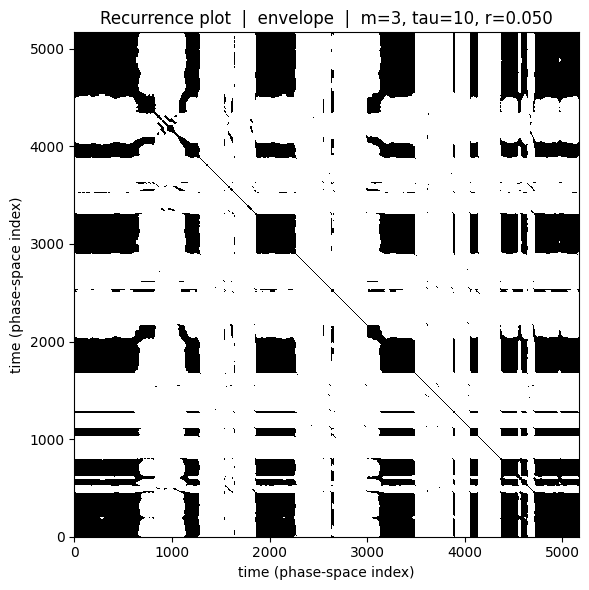

In [13]:
rp_result = RPComputation.create(settings).run()
rp = rp_result.recurrence_matrix_reverse  # 2D binary matrix (origin lower-left)

plt.figure(figsize=(6, 6))
plt.imshow(rp, cmap="Greys", origin="lower", interpolation="none")
plt.title(f"Recurrence plot  |  {COLUMN}  |  m={EMBED_DIM}, tau={TAU}, r={RADIUS:.3f}")
plt.xlabel("time (phase-space index)"); plt.ylabel("time (phase-space index)")
plt.tight_layout(); plt.show()

## Notes

- **Embedding:** For a good `TAU`, use the first minimum of the average mutual information; for `EMBED_DIM`, use a false-nearest-neighbours analysis. The values above are reasonable starting points, not tuned to this signal.
- **Radius:** Fixing recurrence rate (rather than radius) makes RQA comparable across different signals. Tune `TARGET_RR` to taste (1-5% is common).
- **Reuse:** Change `CSV_PATH` and `COLUMN` at the top to run the same analysis on any other time series (e.g. `envelope_norm`, `envelope_change`, or an OpenFace/kinematics column).